In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `c:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned`


In [2]:
using BSON

In [3]:
tt=610     

test1 = BSON.load("inflation_results_replication/results_Inflation_$tt-1.bson")
test2 = BSON.load("inflation_results_replication/results_Inflation_$tt-2.bson")
test6 = BSON.load("inflation_results_replication/results_Inflation_$tt-6.bson")
test12 = BSON.load("inflation_results_replication/results_Inflation_$tt-12.bson")

# res=[Error_RW Error_AR2 Error_AR7 Error_EWD Error_AR2tv Error_EWDtv]

res1=test1["errors"];
res2=test2["errors"];
res6=test6["errors"];
res12=test12["errors"];

# forecasts=[RV_h horizon_forecast_RW horizon_forecast_AR2 horizon_forecast_AR7 horizon_forecast_EWD horizon_forecast_AR2tv horizon_forecast_EWDtv]

forecasts1=test1["forecasts"];
forecasts2=test2["forecasts"];
forecasts6=test6["forecasts"];
forecasts12=test12["forecasts"];

In [4]:
function tvOLS2(x, y, bw, tkernel; singular_ok::Bool = true)
    obs = size(x, 1)
    if length(y) != obs
        error("Dimensions of 'x' and 'y' are not compatible.")
    end

    nvar = size(x, 2)  # number of regressors
    
    theta     = zeros(obs, nvar)
    fitted    = zeros(obs)
    residuals = zeros(obs)
    
    grid = collect(1:obs) ./ obs

    for t in 1:obs
        tau0 = grid .- grid[t]
        kernel_weights = kernel0(tau0, bw, tkernel)
        kernel_weights /= sum(kernel_weights)
        k_idx = findall(kernel_weights .> 0)

        x_temp = x[k_idx, :]
        y_temp = y[k_idx]
        w_temp = kernel_weights[k_idx]

        XW = x_temp .* sqrt.(w_temp)
        yW = y_temp .* sqrt.(w_temp)

        try
            coef = (XW' * XW) \ (XW' * yW)
            theta[t, :] .= coef'
            fitted[t]    = dot(x[t, :], coef)
            residuals[t] = y[t] - fitted[t]

        catch e
            if e isa LinearAlgebra.SingularException
                if singular_ok
                    theta[t, :] .= NaN
                    fitted[t]    = NaN
                    residuals[t] = NaN
                else
                    rethrow(e)
                end
            else
                rethrow(e)
            end
        end
    end

    return (coefficients = theta, fitted = fitted, residuals = residuals)
end




function kernel0(t, bw, tkernel)
    z = t / bw
    if tkernel == "Gaussian"
        return exp.(-0.5 * z.^2) / sqrt(2 * pi)
    elseif tkernel == "Epa" || tkernel == "Epanechnikov"
        return max.(0, 0.75 * (1 .- z.^2))
    elseif tkernel == "onesided"
        return (z.>0).*exp.(-0.5 * z.^2)
    else
        error("Unknown kernel type")
    end
end
function SED_smooth_one(s1,s2,band)
    data=s1.^2 .- s2.^2;
    t=[t for t in 1.0:1.0:length(data)]
    result1 = tvOLS2(t, data, band,"onesided")
    return result1.fitted
end
function plot_pockets_spur_one(err1,err2,bw,bootthr,tit)

    mycolors_pockets=[mycolor[1] mycolor[1] mycolor[3]];
    
    plot(SED_smooth_one(err1,err2,bw),color=:white,ylim=[-0.1,0.2],legend=false,
    framestyle = :box,size=(1000,200),title = tit,
    xticks=(positions,["2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022"])) 
    plot!([[i,j] for (i,j) in find_intervals(SED_smooth_one(err1,err2,bw).>0.0)] ,fill=mycolor[4], fillalpha=0.2,linecolor=:transparent,seriestype=:vspan,label=false)
    plot!([[i,j] for (i,j) in find_intervals(SED_smooth_one(err1,err2,bw).>bootthr)] ,fill=mycolor[3], fillalpha=0.3,linecolor=:transparent,seriestype=:vspan,label=false)
    plot!(SED_smooth_one(err1,err2,bw),color=mycolor[1])
    plot!([0], seriestype="hline",linestyle=:dash,color=mycolor[3])
    plot!(fontfamily="serif-roman",titlefontsize=10, xtickfontsize=10,ytickfontsize=10,ylabelfontsize=10)
end

plot_pockets_spur_one (generic function with 1 method)

### New code

In [5]:
include("src/SED_Thresholds/SEDThresholds.jl")
using .SEDThresholds

In [6]:
# SED smoother comparison
using LinearAlgebra
bw = 0.03

sed_smooth_legacy = SED_smooth_one(res1[][:,1],res1[][:,6],bw);
sed_smooth_new = SEDThresholds.SED_smooth_one(res1[][:,1],res1[][:,6],bw, "one-sided", false);

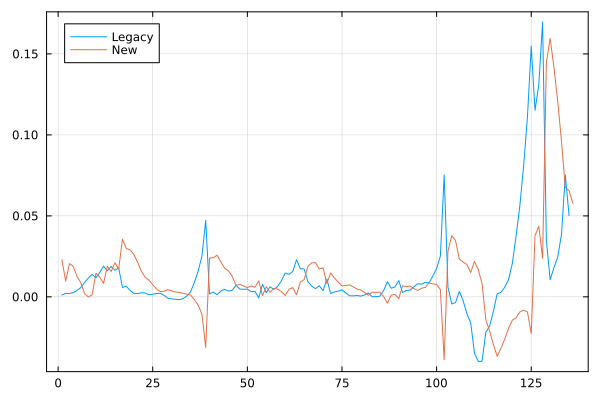

In [7]:
using Plots
display(plot([sed_smooth_legacy sed_smooth_new], label=["Legacy" "New"],frame=:box))

In [8]:
bootthr=[[0.007869 0.0143695 8.35799e-5 0.0039086]
    [0.0200952 0.0249548 0.00395962 0.00647051]
    [0.0568072 0.0613952 0.00968861 0.0137622]
    [0.0934724 0.086612 0.0123735 0.0179216]];

In [17]:
using Dates
# Define the start and end dates
start_date = Date(2011, 6, 1)
end_date = Date(2022, 9, 1)

# Generate monthly dates
monthly_dates = collect(start_date:Month(1):end_date)
beginning_of_year_dates = filter(d -> month(d) == 1, monthly_dates)
positions = findall(d -> month(d) == 1, monthly_dates);
labels = string.(year.(beginning_of_year_dates))

11-element Vector{String}:
 "2012"
 "2013"
 "2014"
 "2015"
 "2016"
 "2017"
 "2018"
 "2019"
 "2020"
 "2021"
 "2022"

### Srovnání s Revision_Inflation_POCKETS_BW.ipynb
- SEDThresholds.SED_smooth_one() z mého modulu má otočené znaménko u one-sided kernelu (viz soubor src/TvPersistence/src/tv_ols.jl funkce kernel()). Pro ostatní kernely se SED curve replikuje správně
- tvLM() používá intercept v regresi, SED_smooth_one() ho nepoužívá, ale v paperu je specifikovaná regrese s interceptem -> další zdroj rozdílu
- Srovnání s funkcí plot_pockets_spur(), která používá R funkci tvLM() vypadá stejně (zde je použit triweight kernel)

In [34]:
bw = 0.03
mycolor=[colorant"rgb(222,102,62)",colorant"rgb(255,145,43)",colorant"rgb(76,144,186)",colorant"rgb(43,194,194)",colorant"rgb(244,184,17)"]

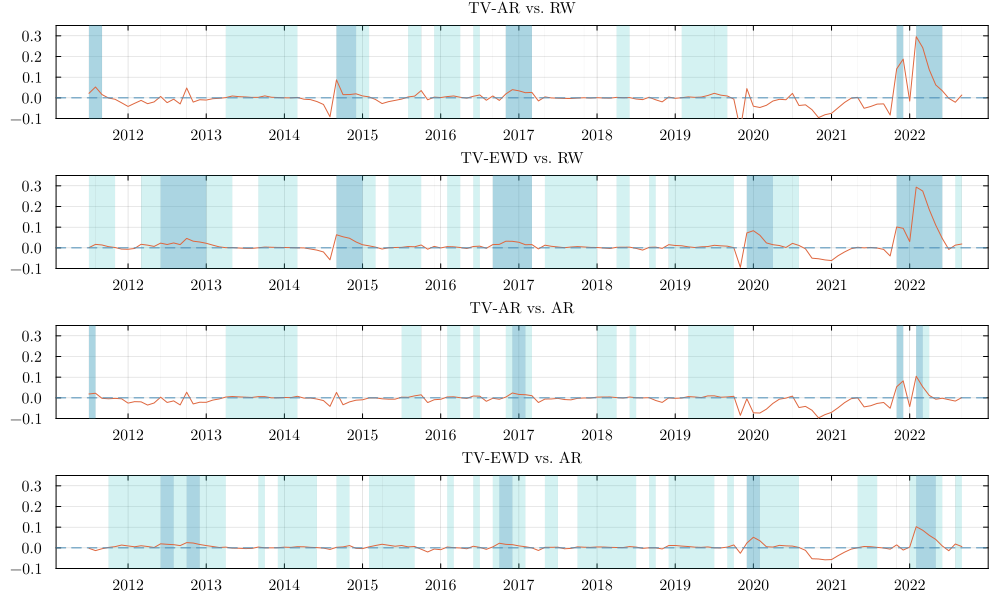

In [39]:
p1 = SEDThresholds.plot_pockets(
    res1[][:,1],
    res1[][:,5],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-AR vs. RW",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p2 = SEDThresholds.plot_pockets(
    res1[][:,1],
    res1[][:,6],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. RW",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p3 = SEDThresholds.plot_pockets(
    res1[][:,2],
    res1[][:,5],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-AR vs. AR",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p4 = SEDThresholds.plot_pockets(
    res1[][:,2],
    res1[][:,6],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. AR",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

pockets_plot = plot(p1,p2,p3,p4,layout = (4,1), legend = false, size = (1000, 600))
plot!(pockets_plot, fontfamily="serif-roman",xtickfontsize=10,ytickfontsize=10, ylim = (-0.1, 0.35))

In [40]:
savefig(pockets_plot, "readme_files/pockets_plot_inflation.pdf")

"c:\\Users\\mikul\\Desktop\\Persistence of Shocks\\tvPersistence.jl - Cleaned\\readme_files\\pockets_plot_inflation.pdf"

In [41]:
mycolor=palette(:Greys_8)

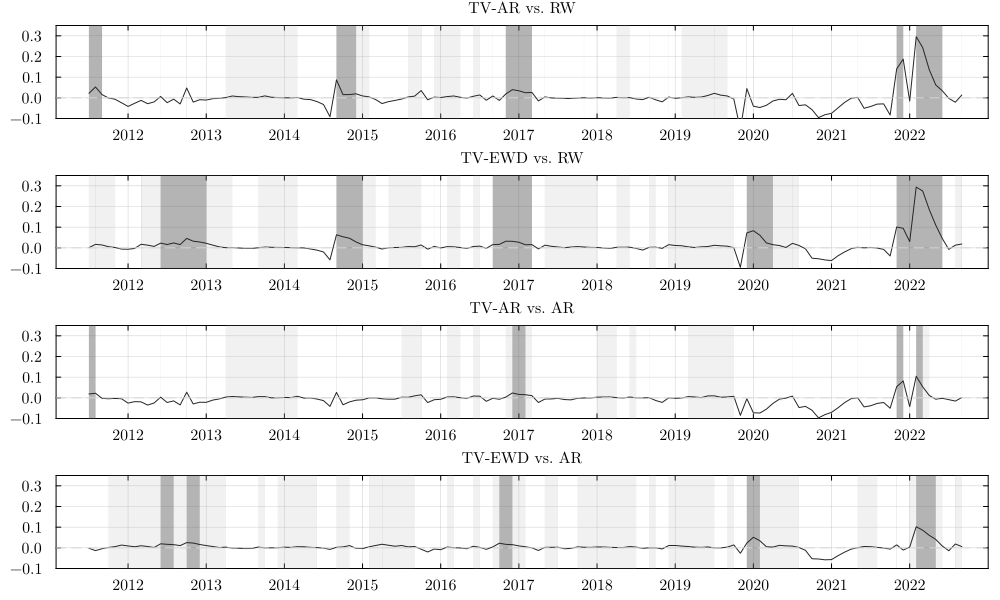

In [42]:
p1 = SEDThresholds.plot_pockets(
    res1[][:,1],
    res1[][:,5],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-AR vs. RW",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[8]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[8],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p2 = SEDThresholds.plot_pockets(
    res1[][:,1],
    res1[][:,6],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. RW",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[8]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[8],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p3 = SEDThresholds.plot_pockets(
    res1[][:,2],
    res1[][:,5],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-AR vs. AR",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[8]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[8],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p4 = SEDThresholds.plot_pockets(
    res1[][:,2],
    res1[][:,6],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. AR",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[8]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[8],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

plot!(p1, ylim=(-0.1, 0.2))

pockets_plot_bw = plot(p1,p2,p3,p4,layout = (4,1), legend = false, size = (1000, 600))
plot!(fontfamily="serif-roman",xtickfontsize=10,ytickfontsize=10, ylim=(-0.1, 0.35)) 

In [43]:
savefig(pockets_plot_bw, "readme_files/pockets_plot_inflation_bw.pdf")

"c:\\Users\\mikul\\Desktop\\Persistence of Shocks\\tvPersistence.jl - Cleaned\\readme_files\\pockets_plot_inflation_bw.pdf"

## Threshold replication

In [18]:
#Pkg.add("RCall")
using RCall

R"library(tvReg)"
R"library(forecast)"

┌ Warning: RCall.jl: Loading required package: Matrix
│ Funded by the Horizon 2020. Framework Programme of the European Union.
│ 
└ @ RCall C:\Users\mikul\.julia\packages\RCall\GLHIY\src\io.jl:171
┌ Warning: RCall.jl: Registered S3 method overwritten by 'quantmod':
│   method            from
│   as.zoo.data.frame zoo 
│ 
│ Attaching package: 'forecast'
│ 
│ The following object is masked from 'package:tvReg':
│ 
│     forecast
│ 
└ @ RCall C:\Users\mikul\.julia\packages\RCall\GLHIY\src\io.jl:171


RObject{StrSxp}
 [1] "forecast"  "tvReg"     "Matrix"    "stats"     "graphics"  "grDevices"
 [7] "utils"     "datasets"  "methods"   "base"     


In [19]:
function SED_smooth(s1,s2,band)
    data=s1.^2 .- s2.^2;
    R"time <- 1:length($data)
    tv_model <- tvLM($data ~ time,bw=$band)
    smoothed_values <- fitted(tv_model)"
    return convert(Array{Float64},R"smoothed_values");
end

SED_smooth (generic function with 1 method)

In [ ]:
tt=610
B=31
test1b = BSON.load("Testing infl threshold_Old method/Inflation_boot_$tt-1.bson")
res1b=test1b["errors"];


In [22]:
data = CSV.read("PCEpi.csv", DataFrame)
data = data[:,1] .* 100;

In [24]:
# RW-TV-EWD
B = 30
bw = 0.1
bP1_RW_TVewd=[SED_smooth(res1b[i][:,1],res1b[i][:,4],bw) for i=1:B];
bP1_RW_TVewd_thr=median([quantile!([bP1_RW_TVewd[j][jj] for j=1:B], 0.95) for jj=1:size(res1b[1],1)])

0.014957791298345577

In [25]:
function compute_global_threshold(
        list_of_sed_vectors::Vector{Vector{Float64}},
        cutoff_start_index::Int,
        alpha_level::Float64 = 0.05
    )::Float64

    B = length(list_of_sed_vectors)
    out_of_sample_length = length(list_of_sed_vectors[1])
    time_cutoffs = Float64[]

    for t in cutoff_start_index:out_of_sample_length
        # collect the B values at time t
        raw_vals = [ list_of_sed_vectors[b][t] for b in 1:B ]
        # drop any NaNs
        clean_vals = filter(!isnan, raw_vals)

        # if everything was NaN you might skip or push a NaN
        if isempty(clean_vals)
            continue
        end

        push!(time_cutoffs, quantile(clean_vals, 1 - alpha_level))
    end

    return median(time_cutoffs)
end

compute_global_threshold (generic function with 2 methods)

In [ ]:
compute_global_threshold(bP1_RW_TVewd, 1, 0.05) # threshold computation fine

0.014957791298345577

In [40]:
test1b_new = BSON.load("SED_values_new.bson");
res1b_new = test1b_new["SED_values"];

In [45]:
bP1_RW_TVewd[1][:, 1]

136-element Vector{Float64}:
 0.005721968435651736
 0.005137887549072169
 0.004657533993122211
 0.004449186418337602
 0.0045051151198278894
 0.004760679347435546
 0.005169674594906919
 0.0056489103980660715
 0.006146024786484424
 0.006698675249738283
 ⋮
 0.004743518987841071
 0.004891378675580177
 0.0051428442141558395
 0.005525582150087034
 0.006033617581629604
 0.006696529202210116
 0.007560155467542101
 0.008680222207520669
 0.01017504931896257

In [42]:
res1b_new[1]

136-element Vector{Float64}:
  0.034736948560652015
  0.026223657325736033
  0.02166330724704154
  0.02021515755117264
  0.021152858240995498
  0.025053740585442116
  0.032281739552655855
  0.04238623671227115
  0.05430999158446083
  0.0668138435327954
  ⋮
  0.06146050961015537
  0.059710695283291454
  0.057024224586284034
  0.053037199002430646
  0.047193197263445175
  0.03889616098883364
  0.02788284387538864
  0.014039051153090787
 -0.00232250590976113

In [43]:
using Plots

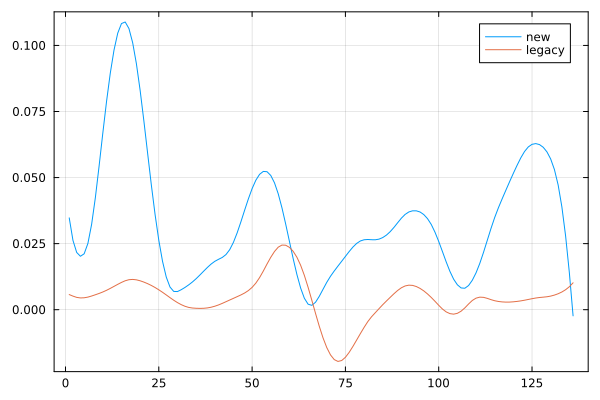

In [46]:
display(plot([res1b_new[1] bP1_RW_TVewd[1][:, 1]], label=["new" "legacy"],frame=:box))

In [126]:
function ARlags_chron(X, p)

    # we lose first p observations if we want to construct lagged matrix
    y = X[p+1:end]

    # Initialize matrix of lagged values
    xx = zeros(length(y), p)

    # for each row, populate the matrix of lagged values with the correct lagged data
    for i in 1:length(y)
        for lag in 1:p
            xx[i, lag] = X[i + p - lag]
        end
    end
    return (y, xx)
end

# Standard OLS estimation
function replace_infs_and_nans_with_zeros(matrix)
    matrix[isinf.(matrix) .| isnan.(matrix)] .= 0
    return matrix
end

# Standard OLS estimator
function OLSestimator(y, x)
    return replace_infs_and_nans_with_zeros((transpose(x)*x)) \ (transpose(x)*y)
end

function fit_ar_model(
        series_vector::Vector{Float64},
        ar_order::Int
    )
    y, lag_matrix = ARlags_chron(series_vector, ar_order)
    T = length(y)  # = length(series_vector) - ar_order

    design_matrix = hcat(ones(T), lag_matrix)  # T × (ar_order+1)
    coefficient_vector = OLSestimator(y, design_matrix)

    fitted_values = design_matrix * coefficient_vector
    residual_vector = y .- fitted_values
    residual_standard_deviation = std(residual_vector)

    return coefficient_vector, residual_standard_deviation, residual_vector
end

function generate_AR_bootstrap_series(series, residuals, AR_coefficients, AR_order, burn_in_size = 0)

    # Check AR order and AR coefficient length match properly
    if (length(AR_coefficients) - 1) != AR_order
        throw(error("number of AR coefficients and AR_order must match"))
    end
    
    T = length(series)

    # Initialize a container for the simulated series
    simulated_series = vcat(series[rand(1:T, AR_order)], zeros(T-AR_order + burn_in_size))

    # Randomly resample residuals with replacement
    sampled_errors = rand(residuals, T + burn_in_size)

    # Calculate simulated values through the AR(p) formula
    for period = AR_order+1:T+burn_in_size
        lagged_values = [1;[simulated_series[period - k] for k in 1:AR_order]...] # append 1 for intercept
        simulated_series[period] = dot(lagged_values, AR_coefficients) + sampled_errors[period]
    end

    return(simulated_series)
    
end

generate_AR_bootstrap_series (generic function with 2 methods)

In [127]:
data = CSV.read("PCEpi.csv", DataFrame)
data = data[:,1] .* 100;

In [128]:
coeffs_new, _, residuals_new = fit_ar_model(data, 1)
coeffs_new

2-element Vector{Float64}:
 0.08317655104290601
 0.6911028341712895

In [129]:
using Random
Random.seed!(1)
B = 30

30

In [130]:
function generate_AR_bootstrap_series_V2(series::Vector{Float64},
                                      residuals::Vector{Float64},
                                      AR_coefficients::Vector{Float64},
                                      AR_order::Int;
                                      burn_in_size::Int = 0)

    # 0) sanity
    @assert length(AR_coefficients) == AR_order + 1 "coef vector must be [intercept, φ₁:φₚ]"

    T = length(series)

    # 1) contiguous initial state (p lags)
    start = rand(AR_order:T)
    init_state = copy(series[start-AR_order+1:start])  # length p

    # 2) total steps to produce after the seed, including burn-in
    steps = T + burn_in_size

    # allocate: seed p + steps values
    simulated_series = Vector{Float64}(undef, AR_order + steps)
    simulated_series[1:AR_order] = init_state

    # 3) resample residuals with replacement (same as legacy after scaling math)
    sampled_errors = rand(residuals, steps)

    # 4) iterate forward; write to the *current* index
    # current index runs from AR_order+1 .. AR_order+steps
    for t = AR_order+1 : AR_order+steps
        # lags: x_{t-1}, x_{t-2}, ..., x_{t-p}
        lags = @view simulated_series[t .- (1:AR_order)]
        simulated_series[t] = AR_coefficients[1] + dot(AR_coefficients[2:end], lags) + sampled_errors[t-AR_order]
    end

    # 5) drop the burn-in and the initial seed; keep the last T values
    out = simulated_series[AR_order + burn_in_size + 1 : AR_order + burn_in_size + T]
    return out
end

generate_AR_bootstrap_series_V2 (generic function with 1 method)

In [138]:
bootstrapped_series_new = []
Random.seed!(1)

for i=1:B
    sed_vals = generate_AR_bootstrap_series(data, residuals_new, coeffs_new, 1)
    push!(bootstrapped_series_new, sed_vals)
end

In [139]:
# Legacy implementaion
dependent = data;
T= length(data)
X = dependent
T -= 1

# Simple OLS to obtain fitted predictive regression residuals
gamma0 = hcat(ones(T), X[1:end-1]) \ X[2:end]

eHatR = X[2:end] .- (hcat(ones(T), X[1:end-1, :]) * gamma0);
uHatR = eHatR ./ std(eHatR); #OK

In [140]:
round.(coeffs_new; digits = 10) == round.(gamma0; digits = 10)

true

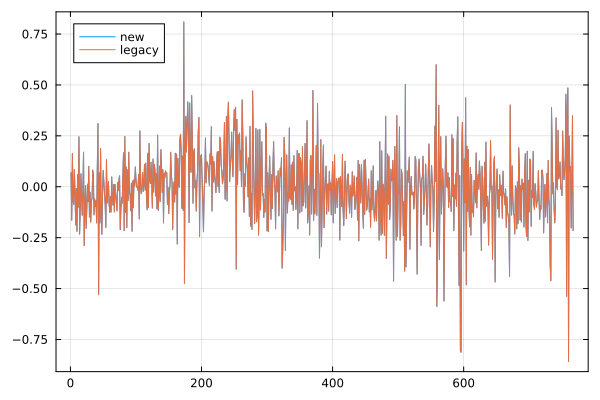

true

In [141]:
display(plot([eHatR residuals_new], label=["new" "legacy"],frame=:box))
round.(eHatR; digits = 10) == round.(residuals_new; digits = 10)

In [142]:
Random.seed!(1)
bootstrapped_series_old = []
burnIn = 0

for i=1:B

    startInd = rand(1:T)

    Xb = vcat(X[startInd, :], zeros(T + burnIn));

# i.i.d. bootstrap index draw ### !!! I took the simple variant !!!
    ind = rand(1:T, T + burnIn + 1)
    ubR = uHatR[ind];
    ebR = ubR*std(eHatR);

    for t in 1:T + burnIn
       Xb[t + 1] = [1; Xb[t, :]]' * gamma0 + ebR[t + 1]
    end
    push!(bootstrapped_series_old, Xb)
end


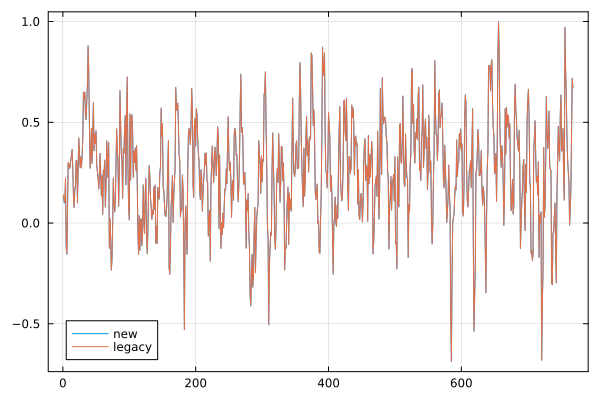

In [145]:
display(plot([bootstrapped_series_new[5] bootstrapped_series_old[5]], label=["new" "legacy"],frame=:box))

In [144]:
for i=1:B
    println(round.(bootstrapped_series_new[i]; digits = 10) == round.(bootstrapped_series_old[i]; digits = 10))
end

true
true
true
true
false
true
true
false
true
true
false
false
false
true
true
false
false
true
false
false
false
false
true
true
false
true
true
true
true
true
